# Speaker Diarization and Summarization Using WavLM
**Artificial Intelligence / Speech Processing Project**

This notebook builds a complete speech-analytics pipeline for multi-speaker audio:

1. **Speaker identification (trained model):** WavLM x-vector embeddings + a small neural classifier head, trained on **80 %** of the data and tested on the unseen **20 %**.
2. **Speaker diarization ("who spoke when"):** sliding-window WavLM embeddings, clustering, and segmentation. Evaluated with **Diarization Error Rate (DER)** on multi-speaker conversations built **only from the 20 % test split**.
3. **Transcription:** OpenAI Whisper transcribes each speaker segment (evaluated with Word Error Rate).
4. **Expressions (emotions):** each segment gets a voice-emotion score (from the audio) and a text-emotion score (from the words).
5. **Summarization:** concise overall and per-speaker summaries generated from the speaker-labelled transcript.
6. **Report:** how many members are speaking, what each one said, their emotions, and talk-time charts.

**Technologies:** Python, WavLM, NLP, Deep Learning, Speech Processing, OpenAI Whisper

**Pipeline**

```
audio -> VAD (energy) -> 1.5 s windows -> WavLM x-vectors -> clustering -> speaker segments
      -> Whisper per segment -> transcript + emotions -> summaries + report
                    \-> classifier head (trained on 80 %) -> speaker names
```

## 1. Install and import

In [1]:
!pip -q install datasets soundfile librosa jiwer accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 46.0 MB/s eta 0:00:00


In [2]:
import os, io, re, json, random, warnings
import numpy as np
import pandas as pd
import torch
import soundfile as sf
import librosa
import matplotlib.pyplot as plt
import jiwer
from IPython.display import display

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

SR = 16000                                   # WavLM and Whisper both use 16 kHz
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


## 2. Configuration
Change `DATA_SOURCE` if you want to use your own recordings.

* `"huggingface"`: downloads a few speakers from LibriSpeech (needs internet).
* `"folder"`: reads your own data from `DATA_DIR`, laid out as one sub-folder per speaker:
  `DATA_DIR/speaker_name/clip1.wav`, `DATA_DIR/speaker_name/clip2.wav`, ...

In [3]:
DATA_SOURCE = "huggingface"        # "huggingface" or "folder"
DATA_DIR    = "/kaggle/input/your-speaker-dataset"   # only used when DATA_SOURCE = "folder"

N_SPEAKERS          = 8            # number of speakers used
UTTS_PER_SPEAKER    = 40           # utterances loaded per speaker
MIN_SEC, MAX_SEC    = 3.0, 15.0    # keep utterances in this duration range
TRAIN_RATIO         = 0.80         # 80 % training  /  20 % testing

WIN, HOP, GRID      = 1.5, 0.75, 0.05   # window length, hop, time-grid resolution (seconds)

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

## 3. Load the speaker dataset

In [19]:
def load_huggingface_speakers(n_speakers, utts_per_speaker, min_sec, max_sec, max_scan=6000):
    from datasets import load_dataset, Audio
    try:
        ds = load_dataset("openslr/librispeech_asr", "clean", split="validation", streaming=True)
        ds = ds.cast_column("audio", Audio(decode=False))      # we decode ourselves with soundfile
    except Exception as e:
        raise RuntimeError(
            "Could not download the dataset (" + type(e).__name__ + ": " + str(e)[:200] + ").\n"
            "Fix: turn Internet ON in the notebook settings, OR set DATA_SOURCE = 'folder' and "
            "point DATA_DIR to your own speaker folders.")
    per, done, scanned = {}, set(), 0
    for ex in ds:
        scanned += 1
        if scanned > max_scan:
            break
        spk = str(ex["speaker_id"])
        if spk in done:
            continue
        if spk not in per:
            if len(per) >= n_speakers:
                continue
            per[spk] = []
        a = ex["audio"]
        if a.get("bytes") is not None:
            wav, sr = sf.read(io.BytesIO(a["bytes"]), dtype="float32")
        else:
            wav, sr = sf.read(a["path"], dtype="float32")
        if wav.ndim > 1:
            wav = wav.mean(axis=1)
        if sr != SR:
            wav = librosa.resample(wav, orig_sr=sr, target_sr=SR)
        dur = len(wav) / SR
        if not (min_sec <= dur <= max_sec):
            continue
        per[spk].append(dict(speaker=spk, audio=wav, text=ex["text"], duration=dur))
        if len(per[spk]) >= utts_per_speaker:
            done.add(spk)
        if len(done) >= n_speakers:
            break
    return [u for spk in per for u in per[spk]]


def load_folder_speakers(root, n_speakers, utts_per_speaker, min_sec, max_sec):
    exts = (".wav", ".flac", ".mp3", ".ogg")
    assert os.path.isdir(root), f"DATA_DIR not found: {root}"
    speakers = sorted(d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d)))[:n_speakers]
    items = []
    for spk in speakers:
        files = []
        for r, _, fs in os.walk(os.path.join(root, spk)):
            files += [os.path.join(r, f) for f in fs if f.lower().endswith(exts)]
        count = 0
        for f in sorted(files):
            wav, _ = librosa.load(f, sr=SR, mono=True)
            if min_sec <= len(wav) / SR <= max_sec:
                items.append(dict(speaker=spk, audio=wav, text="", duration=len(wav) / SR))
                count += 1
            if count >= utts_per_speaker:
                break
    return items


if DATA_SOURCE == "huggingface":
    utts = load_huggingface_speakers(N_SPEAKERS, UTTS_PER_SPEAKER, MIN_SEC, MAX_SEC)
else:
    utts = load_folder_speakers(DATA_DIR, N_SPEAKERS, UTTS_PER_SPEAKER, MIN_SEC, MAX_SEC)

# keep only speakers with enough utterances to split 80/20
counts = pd.Series([u["speaker"] for u in utts]).value_counts()
keep = set(counts[counts >= 10].index)
utts = [u for u in utts if u["speaker"] in keep]

print(f"Loaded {len(utts)} utterances from {len(keep)} speakers")
print(f"Total audio: {sum(u['duration'] for u in utts) / 60:.1f} minutes")
assert len(utts) > 0, "No audio loaded. Check DATA_SOURCE / DATA_DIR."

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Loaded 311 utterances from 8 speakers
Total audio: 36.5 minutes


## 4. Train / test split (80 % / 20 %)
The split is **stratified by speaker**, so every speaker appears in both sets, and it is done on whole utterances.
No test utterance is ever used for training, and the test-set conversations in Section 8 are built only from the 20 % test split.

Train: 248 utterances (80%)
Test : 63 utterances (20%)


,train,test
1673,24,7
1988,32,8
2035,32,8
2086,32,8
2277,32,8
777,32,8
7976,32,8
84,32,8


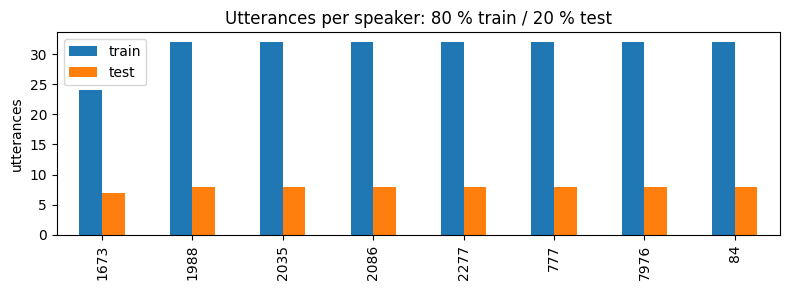

In [5]:
from sklearn.model_selection import train_test_split

labels_all = [u["speaker"] for u in utts]
idx = np.arange(len(utts))
train_idx, test_idx = train_test_split(
    idx, test_size=1 - TRAIN_RATIO, random_state=SEED, stratify=labels_all
)
train_set = [utts[i] for i in train_idx]
test_set  = [utts[i] for i in test_idx]

speaker_names = sorted({u["speaker"] for u in utts})
spk2id = {s: i for i, s in enumerate(speaker_names)}

print(f"Train: {len(train_set)} utterances ({len(train_set)/len(utts):.0%})")
print(f"Test : {len(test_set)} utterances ({len(test_set)/len(utts):.0%})")

split_df = pd.DataFrame({
    "train": pd.Series([u["speaker"] for u in train_set]).value_counts(),
    "test":  pd.Series([u["speaker"] for u in test_set]).value_counts(),
}).fillna(0).astype(int).loc[speaker_names]
display(split_df)
split_df.plot(kind="bar", figsize=(8, 3), title="Utterances per speaker: 80 % train / 20 % test")
plt.ylabel("utterances"); plt.tight_layout(); plt.show()

## 5. WavLM speaker embeddings
We use `microsoft/wavlm-base-plus-sv`, a WavLM model with an x-vector head that turns a speech clip into a 512-dimensional speaker embedding.

In [6]:
from transformers import AutoFeatureExtractor, WavLMForXVector

SV_MODEL = "microsoft/wavlm-base-plus-sv"
feat_ext = AutoFeatureExtractor.from_pretrained(SV_MODEL)
wavlm = WavLMForXVector.from_pretrained(SV_MODEL).to(DEVICE).eval()
print("WavLM loaded. Embedding size:", wavlm.config.xvector_output_dim)


@torch.no_grad()
def embed_batch(wavs):
    # list of 1-D float32 arrays -> (N, 512) L2-normalised embeddings
    inputs = feat_ext(wavs, sampling_rate=SR, return_tensors="pt",
                      padding=True, return_attention_mask=True)
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
    emb = wavlm(**inputs).embeddings
    return torch.nn.functional.normalize(emb, dim=-1).cpu().numpy()


def embed_many(wavs, batch_size=32):
    out = []
    for i in range(0, len(wavs), batch_size):
        out.append(embed_batch(wavs[i:i + batch_size]))
    return np.concatenate(out) if out else np.zeros((0, 512), dtype=np.float32)


def make_windows(audio, win=WIN, hop=HOP):
    # returns (start_times, list_of_window_arrays); short audio -> one window
    n_win, n_hop = int(win * SR), int(hop * SR)
    if len(audio) <= n_win:
        return [0.0], [audio]
    starts = list(range(0, len(audio) - n_win + 1, n_hop))
    return [s / SR for s in starts], [audio[s:s + n_win] for s in starts]

preprocessor_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/58.6k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  405MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/266 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  404MB            

model.safetensors: downloading bytes:           |  0.00B            

WavLM loaded. Embedding size: 512


## 6. Train the speaker-identification head (on the 80 % train split)

In [7]:
def build_window_dataset(dataset):
    X_wavs, y, utt_ids = [], [], []
    for ui, u in enumerate(dataset):
        _, wins = make_windows(u["audio"])
        X_wavs += wins
        y += [spk2id[u["speaker"]]] * len(wins)
        utt_ids += [ui] * len(wins)
    return X_wavs, np.array(y), np.array(utt_ids)

tr_wavs, y_train, tr_utt = build_window_dataset(train_set)
te_wavs, y_test,  te_utt = build_window_dataset(test_set)
print(f"Train windows: {len(tr_wavs)} | Test windows: {len(te_wavs)}")

X_train = embed_many(tr_wavs)
X_test  = embed_many(te_wavs)
print("Embeddings:", X_train.shape, X_test.shape)

Train windows: 2020 | Test windows: 432
Embeddings: (2020, 512) (432, 512)


epoch  10 | loss 0.2389 | train acc 0.959 | test acc 0.938
epoch  20 | loss 0.1376 | train acc 0.971 | test acc 0.956
epoch  30 | loss 0.1008 | train acc 0.981 | test acc 0.961
epoch  40 | loss 0.0852 | train acc 0.983 | test acc 0.965
epoch  50 | loss 0.0767 | train acc 0.985 | test acc 0.968
epoch  60 | loss 0.0635 | train acc 0.987 | test acc 0.968


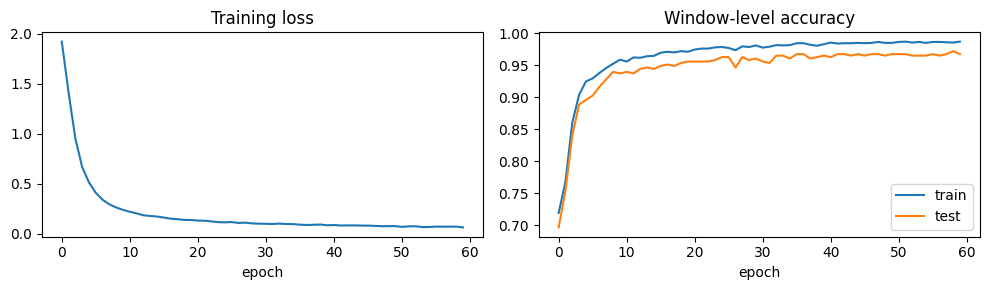

In [8]:
import torch.nn as nn

class SpeakerHead(nn.Module):
    def __init__(self, in_dim, n_classes, hidden=256, p=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(), nn.Dropout(p), nn.Linear(hidden, n_classes)
        )
    def forward(self, x):
        return self.net(x)

N_CLASSES = len(speaker_names)
head = SpeakerHead(X_train.shape[1], N_CLASSES).to(DEVICE)
opt = torch.optim.Adam(head.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn = nn.CrossEntropyLoss()

Xtr = torch.tensor(X_train, dtype=torch.float32, device=DEVICE)
ytr = torch.tensor(y_train, dtype=torch.long, device=DEVICE)
Xte = torch.tensor(X_test,  dtype=torch.float32, device=DEVICE)
yte = torch.tensor(y_test,  dtype=torch.long, device=DEVICE)

EPOCHS, BATCH = 60, 64          # fixed in advance; the test set is NOT used to pick these
hist = {"train_loss": [], "train_acc": [], "test_acc": []}

for ep in range(EPOCHS):
    head.train()
    perm = torch.randperm(len(Xtr), device=DEVICE)
    running = 0.0
    for i in range(0, len(perm), BATCH):
        b = perm[i:i + BATCH]
        opt.zero_grad()
        loss = loss_fn(head(Xtr[b]), ytr[b])
        loss.backward(); opt.step()
        running += loss.item() * len(b)
    head.eval()
    with torch.no_grad():
        tr_acc = (head(Xtr).argmax(1) == ytr).float().mean().item()
        te_acc = (head(Xte).argmax(1) == yte).float().mean().item()
    hist["train_loss"].append(running / len(Xtr)); hist["train_acc"].append(tr_acc); hist["test_acc"].append(te_acc)
    if (ep + 1) % 10 == 0:
        print(f"epoch {ep+1:3d} | loss {hist['train_loss'][-1]:.4f} | train acc {tr_acc:.3f} | test acc {te_acc:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].plot(hist["train_loss"]); ax[0].set_title("Training loss"); ax[0].set_xlabel("epoch")
ax[1].plot(hist["train_acc"], label="train"); ax[1].plot(hist["test_acc"], label="test")
ax[1].set_title("Window-level accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.show()

## 7. Evaluate speaker identification on the 20 % test split
Two levels are reported: **window level** (every 1.5 s window) and **utterance level** (average the window probabilities of each utterance).

Window-level  accuracy: 0.968
Utterance-level accuracy: 0.984

              precision    recall  f1-score   support

        1673       1.00      0.86      0.92         7
        1988       1.00      1.00      1.00         8
        2035       1.00      1.00      1.00         8
        2086       1.00      1.00      1.00         8
        2277       0.89      1.00      0.94         8
         777       1.00      1.00      1.00         8
        7976       1.00      1.00      1.00         8
          84       1.00      1.00      1.00         8

    accuracy                           0.98        63
   macro avg       0.99      0.98      0.98        63
weighted avg       0.99      0.98      0.98        63



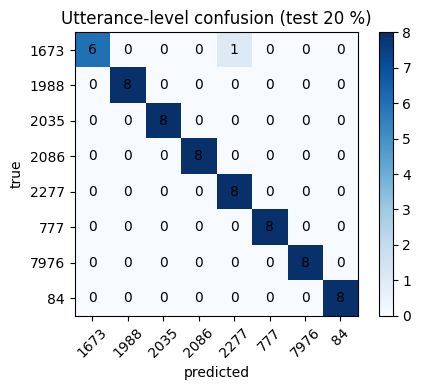

In [9]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

@torch.no_grad()
def predict_proba(emb):
    head.eval()
    x = torch.tensor(emb, dtype=torch.float32, device=DEVICE)
    return torch.softmax(head(x), dim=1).cpu().numpy()

P_test = predict_proba(X_test)
win_pred = P_test.argmax(1)

utt_true, utt_pred = [], []
for ui in range(len(test_set)):
    m = te_utt == ui
    utt_true.append(y_test[m][0])
    utt_pred.append(P_test[m].mean(0).argmax())

print(f"Window-level  accuracy: {accuracy_score(y_test, win_pred):.3f}")
print(f"Utterance-level accuracy: {accuracy_score(utt_true, utt_pred):.3f}\n")
print(classification_report(utt_true, utt_pred, labels=list(range(N_CLASSES)),
                            target_names=speaker_names, zero_division=0))

cm = confusion_matrix(utt_true, utt_pred, labels=list(range(N_CLASSES)))
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(N_CLASSES)); ax.set_xticklabels(speaker_names, rotation=45)
ax.set_yticks(range(N_CLASSES)); ax.set_yticklabels(speaker_names)
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        ax.text(j, i, cm[i, j], ha="center", va="center")
ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title("Utterance-level confusion (test 20 %)")
plt.colorbar(im); plt.tight_layout(); plt.show()

## 8. Speaker diarization
Steps: energy-based voice activity detection, 1.5 s windows (0.75 s hop), WavLM embeddings, agglomerative clustering (cosine distance), frame voting, then segments.
If you do not give the number of speakers, it is chosen automatically with the silhouette score (between 2 and `max_speakers`).

In [10]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

def speech_mask_from_energy(audio, grid=GRID, top_db=35, fill_gap_s=0.4):
    # True for grid frames that contain speech
    g = int(grid * SR)
    n = int(np.ceil(len(audio) / g))
    padded = np.zeros(n * g, dtype=np.float32); padded[:len(audio)] = audio
    rms = np.sqrt((padded.reshape(n, g) ** 2).mean(axis=1) + 1e-12)
    ref = np.percentile(rms, 95)
    mask = (rms > ref * 10 ** (-top_db / 20)) & (rms > 1e-4)
    return fill_short_gaps(mask, int(round(fill_gap_s / grid)))


def fill_short_gaps(mask, max_gap):
    mask = mask.copy(); n = len(mask); i = 0
    while i < n:
        if not mask[i]:
            j = i
            while j < n and not mask[j]:
                j += 1
            if i > 0 and j < n and (j - i) <= max_gap:      # gap between two speech frames
                mask[i:j] = True
            i = j
        else:
            i += 1
    return mask


def cluster_embeddings(E, n_speakers=None, max_speakers=6):
    if len(E) < 2:
        return np.zeros(len(E), dtype=int)
    if n_speakers is None:
        best_k, best_s = 2, -1.0
        for k in range(2, min(max_speakers, len(E) - 1) + 1):
            lab = AgglomerativeClustering(n_clusters=k, metric="cosine", linkage="average").fit_predict(E)
            if len(set(lab)) < 2:
                continue
            s = silhouette_score(E, lab, metric="cosine")
            if s > best_s:
                best_k, best_s = k, s
        n_speakers = best_k
    n_speakers = min(n_speakers, len(E))
    return AgglomerativeClustering(n_clusters=n_speakers, metric="cosine", linkage="average").fit_predict(E)


def windows_to_grid(starts, labels, n_clusters, n_grid, speech_mask, win=WIN, grid=GRID):
    votes = np.zeros((n_grid, n_clusters))
    for s, l in zip(starts, labels):
        a, b = int(round(s / grid)), int(round((s + win) / grid))
        votes[a:b, l] += 1
    lab = np.where(votes.sum(1) > 0, votes.argmax(1), -1)
    lab[~speech_mask[:n_grid]] = -1
    return lab


def grid_to_segments(lab, grid=GRID, min_dur=0.5, merge_gap=0.3):
    segs, start, cur = [], 0, lab[0]
    for i in range(1, len(lab) + 1):
        if i == len(lab) or lab[i] != cur:
            if cur != -1:
                segs.append([start * grid, i * grid, int(cur)])
            if i < len(lab):
                start, cur = i, lab[i]
    merged = []
    for s in segs:
        if merged and merged[-1][2] == s[2] and s[0] - merged[-1][1] <= merge_gap:
            merged[-1][1] = s[1]
        else:
            merged.append(s)
    return [tuple(s) for s in merged if s[1] - s[0] >= min_dur]


def diarize(audio, n_speakers=None, max_speakers=6, min_speech_frac=0.5):
    duration = len(audio) / SR
    n_grid = int(np.ceil(duration / GRID))
    mask = speech_mask_from_energy(audio)

    starts, wins = make_windows(audio)
    keep = []
    for i, s in enumerate(starts):
        a, b = int(s / GRID), int((s + WIN) / GRID)
        if mask[a:b].mean() >= min_speech_frac:
            keep.append(i)
    starts = [starts[i] for i in keep]; wins = [wins[i] for i in keep]
    if len(wins) == 0:
        return dict(segments=[], names={}, embeddings=np.zeros((0, 512)), labels=np.array([]))

    E = embed_many(wins)
    labels = cluster_embeddings(E, n_speakers, max_speakers)
    k = int(labels.max()) + 1
    grid_lab = windows_to_grid(starts, labels, k, n_grid, mask)
    segments = grid_to_segments(grid_lab)

    # name each cluster with the trained classifier head (average probability over the cluster)
    names = {}
    for c in range(k):
        p = predict_proba(E[labels == c]).mean(0)
        names[c] = (speaker_names[int(p.argmax())], float(p.max()))
    return dict(segments=segments, names=names, embeddings=E, labels=labels)

### Diarization Error Rate (DER) and test conversations

In [11]:
from scipy.optimize import linear_sum_assignment

def compute_der(ref_segs, hyp_segs, total_dur, grid=GRID):
    # ref_segs: (start, end, speaker_name); hyp_segs: (start, end, cluster_id)
    n = int(np.ceil(total_dur / grid))
    ref = np.full(n, -1); hyp = np.full(n, -1)
    ref_names = sorted({s[2] for s in ref_segs})
    rmap = {name: i for i, name in enumerate(ref_names)}
    for s, e, sp in ref_segs:
        ref[int(round(s / grid)):int(round(e / grid))] = rmap[sp]
    for s, e, sp in hyp_segs:
        hyp[int(round(s / grid)):int(round(e / grid))] = sp

    both = (ref >= 0) & (hyp >= 0)
    n_hyp = int(hyp.max()) + 1 if (hyp >= 0).any() else 1
    C = np.zeros((len(ref_names), n_hyp))
    for r, h in zip(ref[both], hyp[both]):
        C[r, h] += 1
    ri, ci = linear_sum_assignment(-C)               # best one-to-one speaker mapping
    correct = C[ri, ci].sum()
    ref_speech = max((ref >= 0).sum(), 1)
    miss = ((ref >= 0) & (hyp < 0)).sum()
    fa = ((ref < 0) & (hyp >= 0)).sum()
    conf = both.sum() - correct
    return dict(DER=(miss + fa + conf) / ref_speech, missed=miss / ref_speech,
                false_alarm=fa / ref_speech, confusion=conf / ref_speech)


def build_conversation(dataset, rng, n_speakers=3, n_turns=8, pause=(0.6, 1.2)):
    # builds a multi-speaker recording from utterances (no overlapping speech)
    spk_pool = sorted({u["speaker"] for u in dataset})
    chosen = [str(s) for s in rng.choice(spk_pool, size=min(n_speakers, len(spk_pool)), replace=False)]
    avail = [i for i, u in enumerate(dataset) if u["speaker"] in chosen]
    rng.shuffle(avail)
    audio, segs, refs, t, prev = [], [], [], 0.0, None
    for turn in range(n_turns):
        pick = next((i for i in avail if dataset[i]["speaker"] != prev), None)
        if pick is None:
            break
        avail.remove(pick)
        u = dataset[pick]
        if turn > 0:
            gap = rng.uniform(*pause)
            audio.append((rng.normal(0, 1e-4, int(gap * SR))).astype(np.float32)); t += gap
        audio.append(u["audio"])
        segs.append((t, t + u["duration"], u["speaker"]))
        refs.append(u["text"])
        t += u["duration"]; prev = u["speaker"]
    return dict(audio=np.concatenate(audio).astype(np.float32), segments=segs,
                text=" ".join(refs), speakers=chosen)


rng = np.random.default_rng(SEED)
N_CONV = 4
test_convs = [build_conversation(test_set, rng, n_speakers=min(3, N_SPEAKERS), n_turns=8) for _ in range(N_CONV)]
for i, c in enumerate(test_convs):
    print(f"Conversation {i+1}: {len(c['audio'])/SR:.1f}s, speakers = {c['speakers']}")

Conversation 1: 51.0s, speakers = ['84', '1673', '777']
Conversation 2: 62.8s, speakers = ['7976', '2035', '1673']
Conversation 3: 56.1s, speakers = ['1988', '2035', '1673']
Conversation 4: 53.7s, speakers = ['2277', '84', '1988']


,conversation,true_speakers,found_speakers_auto,DER_auto,DER_known_k,missed,false_alarm,confusion
0,1,3,2,0.386,0.175,0.125,0.000,0.050
1,2,3,2,0.306,0.104,0.103,0.001,0.000
2,3,3,2,0.443,0.156,0.080,0.003,0.072
3,4,3,2,0.580,0.580,0.077,0.001,0.502



Mean DER (auto speaker count): 0.429
Mean DER (known speaker count): 0.254


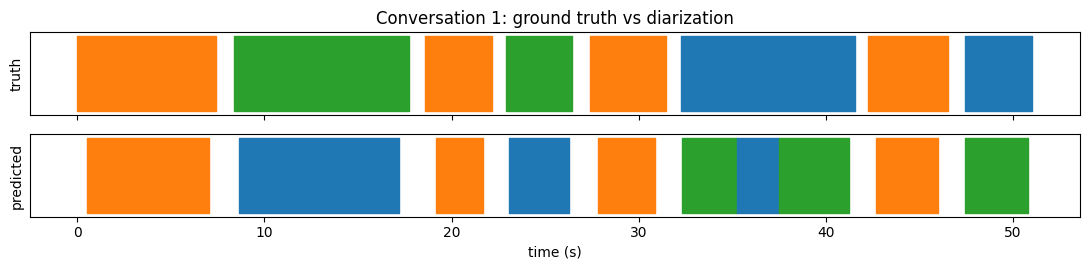

In [12]:
rows = []
for i, c in enumerate(test_convs):
    dur = len(c["audio"]) / SR
    d_auto  = diarize(c["audio"], n_speakers=None)                    # speaker count found automatically
    d_known = diarize(c["audio"], n_speakers=len(c["speakers"]))      # speaker count given
    m_auto  = compute_der(c["segments"], d_auto["segments"], dur)
    m_known = compute_der(c["segments"], d_known["segments"], dur)
    rows.append(dict(conversation=i + 1, true_speakers=len(c["speakers"]),
                     found_speakers_auto=len(d_auto["names"]),
                     DER_auto=round(float(m_auto["DER"]), 3),
                     DER_known_k=round(float(m_known["DER"]), 3),
                     missed=round(float(m_known["missed"]), 3),
                     false_alarm=round(float(m_known["false_alarm"]), 3),
                     confusion=round(float(m_known["confusion"]), 3)))
der_df = pd.DataFrame(rows)
display(der_df)
print(f"\nMean DER (auto speaker count): {der_df['DER_auto'].mean():.3f}")
print(f"Mean DER (known speaker count): {der_df['DER_known_k'].mean():.3f}")


def plot_timeline(ref_segs, hyp_segs, title=""):
    names = sorted({s[2] for s in ref_segs})
    cmap = plt.get_cmap("tab10")
    fig, ax = plt.subplots(2, 1, figsize=(11, 2.8), sharex=True)
    for s, e, sp in ref_segs:
        ax[0].broken_barh([(s, e - s)], (0, 1), color=cmap(names.index(sp) % 10))
    for s, e, cl in hyp_segs:
        ax[1].broken_barh([(s, e - s)], (0, 1), color=cmap(cl % 10))
    ax[0].set_ylabel("truth"); ax[1].set_ylabel("predicted")
    ax[0].set_yticks([]); ax[1].set_yticks([]); ax[1].set_xlabel("time (s)")
    ax[0].set_title(title); plt.tight_layout(); plt.show()

d0 = diarize(test_convs[0]["audio"], n_speakers=len(test_convs[0]["speakers"]))
plot_timeline(test_convs[0]["segments"], d0["segments"], "Conversation 1: ground truth vs diarization")

## 9. Load Whisper, the summarizer and the emotion models
Models are loaded directly (not through `pipeline`) so the notebook works on both old and new versions of `transformers`.

* **Whisper** transcribes each speaker segment. Set `WHISPER_LANGUAGE = None` to auto-detect the language, or `WHISPER_TASK = "translate"` to get English text from other languages (the text-emotion model understands English only).
* **BART** writes the summaries.
* **Voice emotion:** a wav2vec2 audio model (how it sounds). **Text emotion:** a DistilRoBERTa model (what the words mean).

In [13]:
from transformers import (WhisperProcessor, WhisperForConditionalGeneration,
                          AutoTokenizer, AutoModelForSeq2SeqLM,
                          AutoModelForAudioClassification, AutoModelForSequenceClassification)

WHISPER_MODEL    = "openai/whisper-small"      # "openai/whisper-medium" is more accurate but slower
WHISPER_LANGUAGE = "en"                        # None = auto-detect
WHISPER_TASK     = "transcribe"                # or "translate"

whisper_proc = WhisperProcessor.from_pretrained(WHISPER_MODEL)
whisper = WhisperForConditionalGeneration.from_pretrained(WHISPER_MODEL).to(DEVICE).eval()
print("Whisper loaded:", WHISPER_MODEL)

SUM_MODEL = "facebook/bart-large-cnn"
sum_tok = AutoTokenizer.from_pretrained(SUM_MODEL)
sum_model = AutoModelForSeq2SeqLM.from_pretrained(SUM_MODEL).to(DEVICE).eval()
print("Summarizer loaded:", SUM_MODEL)

# ---- voice emotion (audio). Tries the models in order and uses the first that loads ----
VOICE_EMO_CANDIDATES = ["r-f/wav2vec-english-speech-emotion-recognition",
                        "superb/wav2vec2-base-superb-er"]
emo_ext, emo_model = None, None
for _name in VOICE_EMO_CANDIDATES:
    try:
        emo_ext = AutoFeatureExtractor.from_pretrained(_name)
        emo_model = AutoModelForAudioClassification.from_pretrained(_name).to(DEVICE).eval()
        print("Voice-emotion model loaded:", _name, "->", list(emo_model.config.id2label.values()))
        break
    except Exception as e:
        print("Could not load", _name, "->", type(e).__name__)

# ---- text emotion (words) ----
TEXT_EMO_MODEL = "j-hartmann/emotion-english-distilroberta-base"
try:
    txt_tok = AutoTokenizer.from_pretrained(TEXT_EMO_MODEL)
    txt_model = AutoModelForSequenceClassification.from_pretrained(TEXT_EMO_MODEL).to(DEVICE).eval()
    print("Text-emotion model loaded:", TEXT_EMO_MODEL)
except Exception as e:
    txt_tok, txt_model = None, None
    print("Could not load text-emotion model ->", type(e).__name__)

preprocessor_config.json:   0%|          | 0.00/185k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.97k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/283k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/836k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.48M [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  329MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Text-emotion model loaded: j-hartmann/emotion-english-distilroberta-base


## 10. Transcription, expressions and summaries

In [14]:
EMO_MAP = {"neu": "neutral", "hap": "happy", "ang": "angry", "joy": "happy", "anger": "angry",
           "sadness": "sad", "fearful": "fear", "surprised": "surprise", "disgusted": "disgust",
           "calm": "neutral", "happiness": "happy"}
def norm_emotion(label):
    label = label.lower().strip()
    return EMO_MAP.get(label, label)


@torch.no_grad()
def whisper_transcribe(wav):
    texts = []
    n = 30 * SR                                         # Whisper handles 30 s at a time
    for i in range(0, len(wav), n):
        chunk = wav[i:i + n]
        if len(chunk) < int(0.3 * SR):
            continue
        feats = whisper_proc(chunk, sampling_rate=SR, return_tensors="pt").input_features.to(DEVICE)
        kw = dict(task=WHISPER_TASK, max_new_tokens=220)
        if WHISPER_LANGUAGE:
            kw["language"] = WHISPER_LANGUAGE
        ids = whisper.generate(feats, **kw)
        texts.append(whisper_proc.batch_decode(ids, skip_special_tokens=True)[0].strip())
    return " ".join(texts).strip()


@torch.no_grad()
def voice_emotion(wav):
    # average emotion probabilities over 8-second pieces of the segment
    if emo_model is None:
        return {}
    step, probs = 8 * SR, []
    for i in range(0, len(wav), step):
        piece = wav[i:i + step]
        if len(piece) < int(0.5 * SR):
            continue
        inp = emo_ext(piece, sampling_rate=SR, return_tensors="pt", padding=True)
        inp = {k: v.to(DEVICE) for k, v in inp.items()}
        probs.append(torch.softmax(emo_model(**inp).logits, dim=-1)[0].cpu().numpy())
    if not probs:
        return {}
    p = np.mean(probs, axis=0)
    out = {}
    for i, v in enumerate(p):
        k = norm_emotion(emo_model.config.id2label[i])
        out[k] = out.get(k, 0.0) + float(v)
    return out


@torch.no_grad()
def text_emotion(text):
    if txt_model is None or not text.strip():
        return {}
    inp = txt_tok(text, return_tensors="pt", truncation=True, max_length=256).to(DEVICE)
    p = torch.softmax(txt_model(**inp).logits, dim=-1)[0].cpu().numpy()
    out = {}
    for i, v in enumerate(p):
        k = norm_emotion(txt_model.config.id2label[i])
        out[k] = out.get(k, 0.0) + float(v)
    return out


def fuse_emotions(d1, d2):
    if not d1 and not d2:
        return {"neutral": 1.0}
    if not d1: return dict(d2)
    if not d2: return dict(d1)
    return {k: (d1.get(k, 0.0) + d2.get(k, 0.0)) / 2 for k in set(d1) | set(d2)}


def transcribe_segments(audio, segments, pad=0.1):
    out = []
    for s, e, cl in segments:
        a, b = max(0, int((s - pad) * SR)), min(len(audio), int((e + pad) * SR))
        clip = audio[a:b]
        try:
            text = whisper_transcribe(clip)
        except Exception as ex:
            print(f"Whisper failed on segment {s:.1f}-{e:.1f}s: {type(ex).__name__}")
            text = ""
        v_emo, t_emo = voice_emotion(clip), text_emotion(text)
        fused = fuse_emotions(v_emo, t_emo)
        top = max(fused, key=fused.get)
        out.append(dict(start=round(s, 2), end=round(e, 2), cluster=int(cl), text=text,
                        voice_emotion=max(v_emo, key=v_emo.get) if v_emo else "n/a",
                        text_emotion=max(t_emo, key=t_emo.get) if t_emo else "n/a",
                        emotion=top, emotion_score=round(fused[top], 3),
                        emotion_dist={k: round(v, 4) for k, v in fused.items()}))
    return out


@torch.no_grad()
def bart_summarize(text, max_len, min_len):
    inp = sum_tok(text, return_tensors="pt", truncation=True, max_length=1024).to(DEVICE)
    out = sum_model.generate(**inp, num_beams=4, max_length=max_len, min_length=min_len,
                             no_repeat_ngram_size=3, early_stopping=True)
    return sum_tok.decode(out[0], skip_special_tokens=True).strip()


def summarize_text(text, chunk_words=500):
    words = text.split()
    if len(words) < 40:
        return text.strip()                                   # already short
    chunks = [" ".join(words[i:i + chunk_words]) for i in range(0, len(words), chunk_words)]
    parts = []
    for ch in chunks:
        n = len(ch.split())
        parts.append(bart_summarize(ch, min(130, max(25, int(n * 0.6))), min(30, max(10, int(n * 0.2)))))
    joined = " ".join(parts)
    if len(chunks) > 1 and len(joined.split()) >= 40:         # one extra pass to merge chunk summaries
        n = len(joined.split())
        return bart_summarize(joined, min(150, max(25, int(n * 0.6))), min(40, max(10, int(n * 0.2))))
    return joined


def norm_text(t):
    return " ".join(re.sub(r"[^a-z' ]", " ", t.lower()).split())


def write_rttm(path, file_id, segments):
    with open(path, "w") as f:
        for s, e, cl in segments:
            f.write(f"SPEAKER {file_id} 1 {s:.3f} {e - s:.3f} <NA> <NA> speaker_{cl} <NA> <NA>\n")

In [15]:
EMOJI = {"happy": "😊", "angry": "😠", "sad": "😢", "fear": "😨",
         "surprise": "😲", "disgust": "🤢", "neutral": "😐"}
EMO_COLOR = {"happy": "#f2c744", "angry": "#d9534f", "sad": "#5b8def", "fear": "#8e6bbf",
             "surprise": "#f08a24", "disgust": "#6aa84f", "neutral": "#b8b8b8"}


def speaker_table(tr, names):
    # one row per speaker: turns, talk time, share, dominant emotion
    total = sum(t["end"] - t["start"] for t in tr) or 1.0
    rows = []
    for c in sorted({t["cluster"] for t in tr}):
        ts = [t for t in tr if t["cluster"] == c]
        talk = sum(t["end"] - t["start"] for t in ts)
        dist = {}
        for t in ts:
            w = t["end"] - t["start"]
            for k, v in t["emotion_dist"].items():
                dist[k] = dist.get(k, 0.0) + v * w
        z = sum(dist.values()) or 1.0
        dist = {k: v / z for k, v in dist.items()}
        top = max(dist, key=dist.get)
        rows.append(dict(speaker=f"Speaker {c + 1}", cluster=int(c), identified_as=names[c][0],
                         turns=len(ts), talk_time_s=round(talk, 1), share_pct=round(100 * talk / total, 1),
                         words=sum(len(t["text"].split()) for t in ts),
                         dominant_emotion=top, emotion_dist={k: round(v, 3) for k, v in dist.items()}))
    return rows


def show_report(result):
    tr, rows = result["segments"], result["speakers"]
    print("=" * 78)
    print(f"👥  {len(rows)} SPEAKER(S) DETECTED   |   {len(tr)} speaking turns")
    print("=" * 78)

    for r in rows:
        em = r["dominant_emotion"]
        print(f"\n🎙  {r['speaker']}  (identified as: {r['identified_as']})")
        print(f"    {r['turns']} turns | {r['talk_time_s']} s ({r['share_pct']} % of talk time) "
              f"| {r['words']} words | overall expression: {EMOJI.get(em, '')} {em}")
        print(f"    Summary: {result['per_speaker_summary'][r['speaker']]}")
        print("    What they said:")
        for t in [t for t in tr if t["cluster"] == r["cluster"]]:
            print(f"      [{t['start']:6.1f}s-{t['end']:6.1f}s] {EMOJI.get(t['emotion'], '')} {t['emotion']:<8}"
                  f" (voice: {t['voice_emotion']}, words: {t['text_emotion']})  \"{t['text']}\"")

    print("\n" + "-" * 78 + "\nOVERALL SUMMARY\n" + "-" * 78)
    print(result["summary"])

    # tables
    overview = pd.DataFrame([{k: v for k, v in r.items() if k not in ("cluster", "emotion_dist")} for r in rows])
    overview["dominant_emotion"] = overview["dominant_emotion"].map(lambda e: f"{EMOJI.get(e, '')} {e}")
    print("\nSPEAKER OVERVIEW"); display(overview)

    turns = pd.DataFrame([dict(time=f"{t['start']:.1f}-{t['end']:.1f}s", speaker=t["speaker"],
                               said=t["text"], voice_emotion=t["voice_emotion"],
                               text_emotion=t["text_emotion"],
                               expression=f"{EMOJI.get(t['emotion'], '')} {t['emotion']} ({t['emotion_score']:.2f})")
                          for t in tr])
    print("\nWHO SAID WHAT, AND HOW"); display(turns)

    # charts
    labels = [r["speaker"] for r in rows]
    emos = sorted({k for r in rows for k in r["emotion_dist"]})
    fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
    ax[0].bar(labels, [r["talk_time_s"] for r in rows], color="#4c78a8")
    ax[0].set_title("Talk time per speaker (s)"); ax[0].set_ylabel("seconds")
    bottom = np.zeros(len(rows))
    for e in emos:
        vals = np.array([r["emotion_dist"].get(e, 0.0) for r in rows])
        ax[1].bar(labels, vals, bottom=bottom, color=EMO_COLOR.get(e, "#999"), label=e)
        bottom += vals
    ax[1].set_title("Expression mix per speaker"); ax[1].legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout(); plt.show()

    fig, ax = plt.subplots(figsize=(11, 0.7 * len(rows) + 1.2))
    for t in tr:
        ax.broken_barh([(t["start"], t["end"] - t["start"])], (t["cluster"] - 0.4, 0.8),
                       color=EMO_COLOR.get(t["emotion"], "#999"))
    ax.set_yticks([r["cluster"] for r in rows]); ax.set_yticklabels(labels)
    ax.set_xlabel("time (s)"); ax.set_title("Who spoke when, coloured by expression")
    handles = [plt.Rectangle((0, 0), 1, 1, color=EMO_COLOR.get(e, "#999")) for e in emos]
    ax.legend(handles, emos, fontsize=8, ncol=len(emos), loc="upper center", bbox_to_anchor=(0.5, -0.25))
    plt.tight_layout(); plt.show()

[transformers] Passing `generation_config` together with generation-related arguments=({'suppress_tokens', 'begin_suppress_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=220) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer WhisperTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[transformers] Both `max_ne

👥  3 SPEAKER(S) DETECTED   |   10 speaking turns

🎙  Speaker 1  (identified as: 84)
    3 turns | 14.0 s (35.6 % of talk time) | 42 words | overall expression: 😐 neutral
    Summary: Now Helicon must need poor forth for me, and with her choir Urania must assist me to put in
    What they said:
      [   8.7s-  17.2s] 😢 sad      (voice: angry, words: sad)  "Now Helicon must need poor forth for me, and with her choir Urania must assist me to put in verse things difficult to think."
      [  23.1s-  26.3s] 😨 fear     (voice: disgust, words: fear)  "Morrell suffered an exclamation of horror and surprise to escape him."
      [  35.2s-  37.5s] 😐 neutral  (voice: disgust, words: neutral)  "rank, defended his cause by a modest"

🎙  Speaker 2  (identified as: 777)
    4 turns | 15.4 s (39.0 % of talk time) | 67 words | overall expression: 😐 neutral
    Summary: Don't you think that, if I had not been the optimist I am, I could not have found in 15 years some means to cut my throat? He gave the

,speaker,identified_as,turns,talk_time_s,share_pct,words,dominant_emotion
0,Speaker 1,84,3,14.0,35.6,42,😐 neutral
1,Speaker 2,777,4,15.4,39.0,67,😐 neutral
2,Speaker 3,1673,3,10.0,25.4,28,😠 angry



WHO SAID WHAT, AND HOW


,time,speaker,said,voice_emotion,text_emotion,expression
0,0.5-7.0s,Speaker 2,"Don't you think that, if I had not been the op...",angry,surprise,😲 surprise (0.30)
1,8.7-17.2s,Speaker 1,"Now Helicon must need poor forth for me, and w...",angry,sad,😢 sad (0.28)
2,19.1-21.7s,Speaker 2,He gave the discussion up with a slight shrug ...,disgust,neutral,😐 neutral (0.42)
3,23.1-26.3s,Speaker 1,Morrell suffered an exclamation of horror and ...,disgust,fear,😨 fear (0.53)
4,27.9-30.9s,Speaker 2,"You would call that latter degenerate, would y...",disgust,disgust,🤢 disgust (0.39)
5,32.3-35.2s,Speaker 3,68 bishops 22 of metropolitan,disgust,neutral,😐 neutral (0.48)
6,35.2-37.5s,Speaker 1,"rank, defended his cause by a modest",disgust,neutral,😐 neutral (0.37)
7,37.5-41.2s,Speaker 3,and temperate protest. They were excluded from...,disgust,angry,😠 angry (0.56)
8,42.7-46.0s,Speaker 2,and ever since he had never managed to get his...,disgust,neutral,😐 neutral (0.49)
9,47.5-50.8s,Speaker 3,But the Vatican recede with open arms the mess...,angry,disgust,🤢 disgust (0.28)


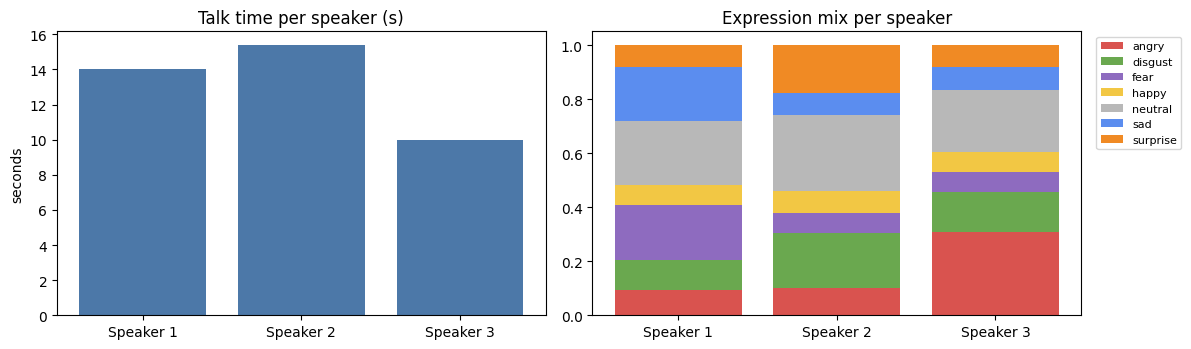

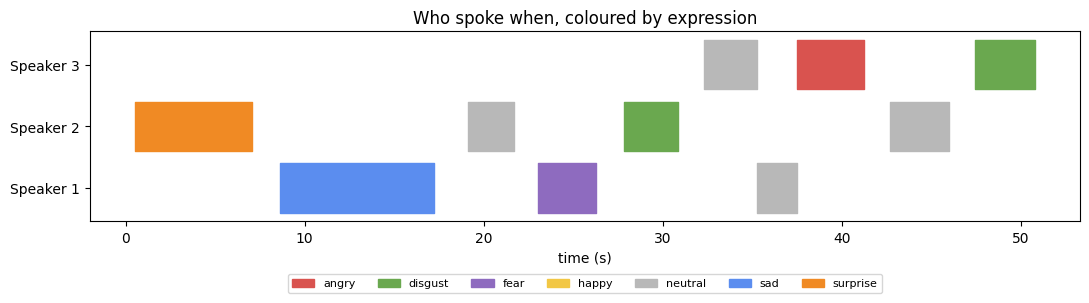


Word Error Rate (Whisper): 0.100


In [16]:
def run_pipeline(audio, name="recording", n_speakers=None, ref_text=None, verbose=True):
    # full pipeline: diarize -> identify -> transcribe -> emotions -> summarize -> report -> save
    d = diarize(audio, n_speakers=n_speakers)
    if not d["segments"]:
        print("No speech detected in this audio.")
        return None
    tr = transcribe_segments(audio, d["segments"])
    for t in tr:
        t["speaker"] = f"Speaker {t['cluster'] + 1}"
        t["identified_as"] = d["names"][t["cluster"]][0]

    full_text = " ".join(t["text"] for t in tr)
    rows = speaker_table(tr, d["names"])
    per_speaker = {r["speaker"]: summarize_text(" ".join(t["text"] for t in tr if t["cluster"] == r["cluster"]))
                   for r in rows}
    result = dict(name=name, n_speakers=len(rows), segments=tr, speakers=rows,
                  summary=summarize_text(full_text), per_speaker_summary=per_speaker)
    if ref_text:
        result["WER"] = float(jiwer.wer(norm_text(ref_text), norm_text(full_text)))

    write_rttm(os.path.join(OUTPUT_DIR, f"{name}.rttm"), name, d["segments"])
    with open(os.path.join(OUTPUT_DIR, f"{name}.json"), "w", encoding="utf-8") as f:
        json.dump(result, f, indent=2, ensure_ascii=False)

    if verbose:
        show_report(result)
        if "WER" in result:
            print(f"\nWord Error Rate (Whisper): {result['WER']:.3f}")
    return result

res = run_pipeline(test_convs[0]["audio"], name="test_conversation_1",
                   n_speakers=len(test_convs[0]["speakers"]), ref_text=test_convs[0]["text"] or None)

## 11. Final evaluation on all test conversations (20 % split)

In [17]:
rows = []
for i, c in enumerate(test_convs):
    k = len(c["speakers"])
    d = diarize(c["audio"], n_speakers=k)
    m = compute_der(c["segments"], d["segments"], len(c["audio"]) / SR)
    r = run_pipeline(c["audio"], name=f"test_conversation_{i+1}", n_speakers=k,
                     ref_text=c["text"] or None, verbose=False)
    if r is None:
        continue
    rows.append(dict(conversation=i + 1, DER=round(float(m["DER"]), 3),
                     WER=round(r.get("WER", float("nan")), 3),
                     summary_words=len(r["summary"].split())))
final_df = pd.DataFrame(rows)
display(final_df)

print("\n===== FINAL RESULTS (unseen 20 % test split) =====")
print(f"Speaker ID accuracy (utterance level): {accuracy_score(utt_true, utt_pred):.3f}")
print(f"Speaker ID accuracy (window level)   : {accuracy_score(y_test, win_pred):.3f}")
print(f"Mean DER (known speaker count)      : {final_df['DER'].mean():.3f}")
print(f"Mean WER (Whisper)                   : {final_df['WER'].mean():.3f}")
final_df.to_csv(os.path.join(OUTPUT_DIR, "final_results.csv"), index=False)

[transformers] Both `max_new_tokens` (=220) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=220) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=220) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=220) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface

,conversation,DER,WER,summary_words
0,1,0.175,0.100,51
1,2,0.104,0.031,37
2,3,0.156,0.081,38
3,4,0.580,0.006,55



===== FINAL RESULTS (unseen 20 % test split) =====
Speaker ID accuracy (utterance level): 0.984
Speaker ID accuracy (window level)   : 0.968
Mean DER (known speaker count)      : 0.254
Mean WER (Whisper)                   : 0.055


## 12. Run on your own recording (optional)
Set `AUDIO_PATH` to any `.wav`, `.mp3` or `.flac` file with several speakers (meeting, interview, podcast).
This is where the **expression** analysis is most useful, because real conversations contain real emotion.
Leave `NUM_SPEAKERS = None` to detect the speaker count automatically.

In [18]:
AUDIO_PATH   = "/kaggle/input/your-audio/meeting.wav"     # Windows example: r"C:\Users\you\Desktop\meeting.wav"
NUM_SPEAKERS = None

if os.path.exists(AUDIO_PATH):
    my_audio, _ = librosa.load(AUDIO_PATH, sr=SR, mono=True)
    print(f"Loaded {len(my_audio)/SR:.1f} seconds of audio")
    my_result = run_pipeline(my_audio, name="my_recording", n_speakers=NUM_SPEAKERS)
else:
    print("Set AUDIO_PATH to your own file to run this cell. Skipping.")

Set AUDIO_PATH to your own file to run this cell. Skipping.


## 13. Summary and limitations

* **What was built:** WavLM x-vector embeddings, a trained speaker-identification head (80 % train / 20 % test), clustering-based diarization with DER evaluation, per-segment Whisper transcription, and BART summaries.
* **Test conversations** are built by joining unseen test utterances with pauses, so they contain no overlapping speech. Real meetings with interruptions will give a higher DER.
* **Speaker names** come from the trained head, so they are only meaningful for speakers present in training. Unknown speakers still get a cluster label (`Speaker N`) but may be given the wrong name.
* **Automatic speaker count** uses the silhouette score, always chooses at least 2 speakers, and can over- or under-estimate. Section 8 reports DER both ways. Set `NUM_SPEAKERS` if you know the count.
* **Expressions** come from pretrained emotion models (voice + words). The test conversations are read-aloud book passages, so they are mostly *neutral*; use emotional or conversational audio (Section 12) to see more variety. Emotion models trained on acted speech are less reliable on real, noisy recordings.
* **Summaries** work best on real conversational or narrative speech. Read-aloud book passages (LibriSpeech) produce valid but less meaningful summaries.
* **Improvements:** overlapped-speech handling, a neural VAD, fine-tuning WavLM end-to-end, and a larger Whisper model.